In [1]:
from pydantic import BaseModel
from langgraph.graph import StateGraph ,START,END


In [2]:
class  GreetState(BaseModel):
    message:str=""
    

In [23]:
graph=StateGraph(GreetState)

### Nodes- Python Function

In [32]:
def Greet(state:GreetState):
    state.message=f"{state.message} | Hello How You?"
    return state

def upperCase(state:GreetState):
    state.message=state.message.upper()
    return state

In [25]:
graph.add_node("greet",Greet)

In [33]:
graph.add_node("upperCase",upperCase)

Adding a node to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [34]:
graph.add_edge(START,"greet")
graph.add_edge("greet","upperCase")
graph.add_edge("greet","upperCase")
graph.add_edge("greet",END)

Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.
Adding an edge to a graph that has already been compiled. This will not be reflected in the compiled graph.


In [35]:
finalGraph=graph.compile()

In [36]:
res=finalGraph.invoke({"message":"I love langgraph"})

In [37]:
res

{'message': 'I LOVE LANGGRAPH | HELLO HOW YOU?'}

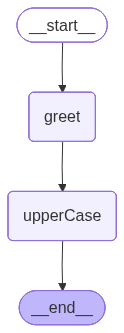

In [38]:
from IPython.display import Image
Image(finalGraph.get_graph().draw_mermaid_png())